In [2]:
!pip install pysal mgwr -q

In [3]:
import geopandas as gpd
import numpy as np
from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW
from mgwr.utils import shift_colormap
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [4]:
# === 1. Ler o geopackage ===
gdf = gpd.read_file("mun_ods.gpkg")

# === 2. Remover linhas com valores nulos ===
gdf = gdf.dropna(subset=['ODS_score', 'PIB_percap'])

# === 3. Extrair coordenadas dos centróides ===
gdf['x'] = gdf.geometry.centroid.x
gdf['y'] = gdf.geometry.centroid.y
coords = list(zip(gdf['x'], gdf['y']))

# === 4. Preparar variáveis ===
y = gdf[['ODS_score']].values
X = gdf[['PIB_percap']].values

# Normalizar os dados para estabilidade numérica
scaler_y = StandardScaler()
scaler_X = StandardScaler()

y_std = scaler_y.fit_transform(y)
X_std = scaler_X.fit_transform(X)

# === 5. Selecionar bandwidth ótimo ===
bw = Sel_BW(coords, y_std, X_std).search(bw_min=20)

# === 6. Rodar GWR ===
gwr_model = GWR(coords, y_std, X_std, bw)
gwr_results = gwr_model.fit()

print(gwr_results.summary())

/tmp/ipython-input-3425248267.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['x'] = gdf.geometry.centroid.x
/tmp/ipython-input-3425248267.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['y'] = gdf.geometry.centroid.y


Model type                                                         Gaussian
Number of observations:                                                5570
Number of covariates:                                                     2

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                           5024.342
Log-likelihood:                                                   -7616.352
AIC:                                                              15236.705
AICc:                                                             15238.709
BIC:                                                             -43000.495
R2:                                                                   0.098
Adj. R2:                                                              0.098

Variable                              Est.         SE  t(Est/SE)    p-value
------------------------------- ---------- ---------- ------

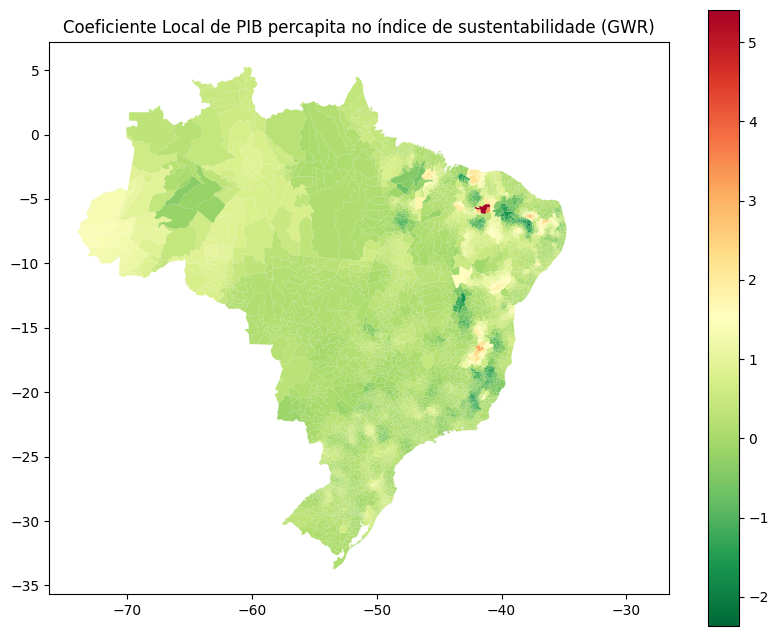

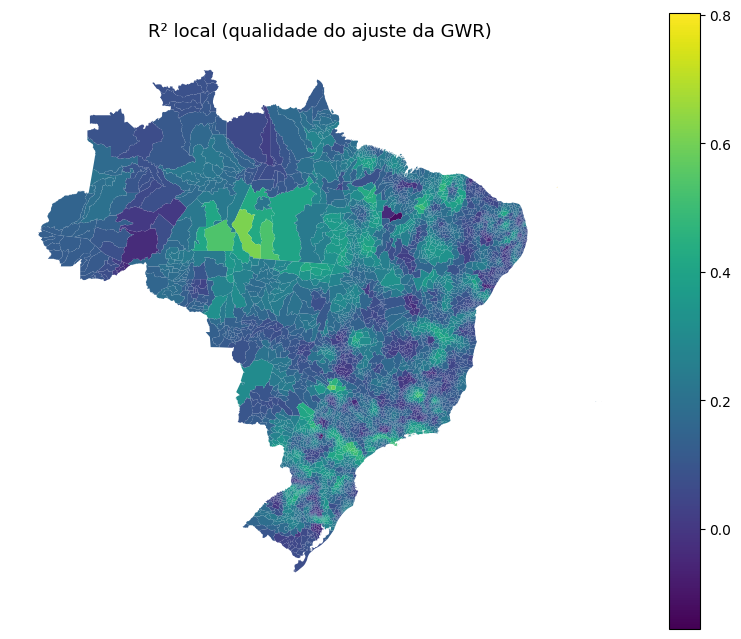

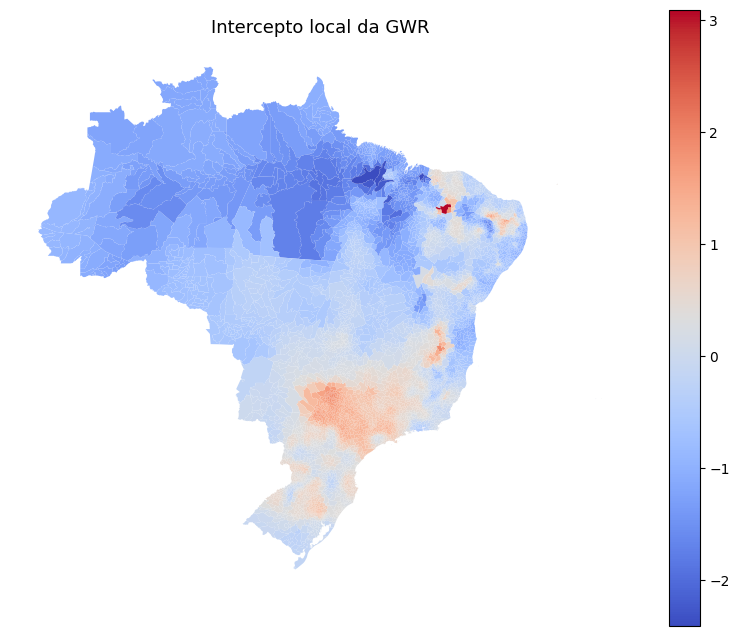

In [5]:
# === 7. Adicionar coeficientes ao GeoDataFrame ===
gdf['Intercept'] = gwr_results.params[:, 0]
gdf['Coef_PIB'] = gwr_results.params[:, 1]
gdf['R2_local'] = gwr_results.localR2

# === 8. Salvar resultado ===
gdf.to_file("mun_ods_gwr.gpkg", driver="GPKG")


# === 9. Visualização ===
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
gdf.plot(column='Coef_PIB', cmap='RdYlGn_r', legend=True, ax=ax)
ax.set_title('Coeficiente Local de PIB percapita no índice de sustentabilidade (GWR)')
plt.show()

fig, ax = plt.subplots(figsize=(10,8))
gdf.plot(column='R2_local', cmap='viridis', legend=True, ax=ax)
ax.set_title('R² local (qualidade do ajuste da GWR)', fontsize=13)
ax.axis('off')
plt.show()

fig, ax = plt.subplots(figsize=(10,8))
gdf.plot(column='Intercept', cmap='coolwarm', legend=True, ax=ax)
ax.set_title('Intercepto local da GWR', fontsize=13)
ax.axis('off')
plt.show()




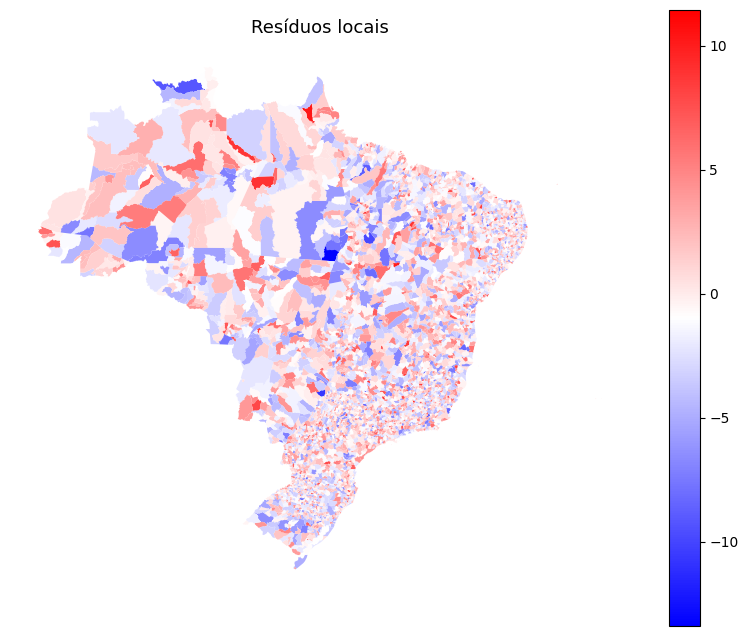

In [6]:
# Valor previsto (em escala padronizada)
y_pred = gwr_results.predy
# Voltar à escala original
y_pred_original = y_pred * gdf['ODS_score'].std() + gdf['ODS_score'].mean()

# Calcular resíduos
gdf['Residuo'] = gdf['ODS_score'] - y_pred_original.flatten()

# Visualizar
fig, ax = plt.subplots(figsize=(10,8))
gdf.plot(column='Residuo', cmap='bwr', legend=True, ax=ax)
ax.set_title('Resíduos locais', fontsize=13)
ax.axis('off')
plt.show()
